### Importing Libraries

In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

GPU Usage?

In [2]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using the GPU!")

    gpus = tf.config.list_physical_devices('GPU')
    print("Available GPUs:", gpus)

    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU Details:", details)
else:
    print("TensorFlow is using the CPU.")

TensorFlow is using the GPU!
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Details: {'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU', 'compute_capability': (8, 6)}


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model

class ClassBalancedFocalLoss(tf.keras.losses.Loss):
    
    def __init__(self, alpha=0.25, gamma=2.0, name="focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
        loss = alpha_t * tf.math.pow((1 - p_t), self.gamma) * cross_entropy
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha": self.alpha,
            "gamma": self.gamma,
        })
        return config


class AdaMed(tf.keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, gamma_align=0.1, weight_decay=1e-4, epsilon=1e-7, name="AdaMed", **kwargs):
        super().__init__(name=name, **kwargs)
        self._set_hyper("learning_rate", kwargs.get("lr", learning_rate))
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.gamma_align = gamma_align
        self.weight_decay = weight_decay
        self.epsilon = epsilon
        
    def _create_slots(self, var_list):
        for var in var_list:
            self.add_slot(var, "m")
            self.add_slot(var, "v")
            
    def _resource_apply_dense(self, grad, var, apply_state=None):
        m = self.get_slot(var, "m")
        v = self.get_slot(var, "v")
        lr = self._get_hyper("learning_rate")
        
        dot_product = tf.reduce_sum(grad * m)
        norm_g = tf.norm(grad)
        norm_m = tf.norm(m)
        rho_t = tf.clip_by_value(dot_product / (norm_g * norm_m + self.epsilon), 0.0, 1.0)
        
        m_t = self.beta_1 * m + (1.0 - self.beta_1) * (1.0 + self.gamma_align * rho_t) * grad
        v_t = self.beta_2 * v + (1.0 - self.beta_2) * tf.square(grad)
        
        wd = self.weight_decay * (2.0 - rho_t)
        var_t = var - lr * (m_t / (tf.sqrt(v_t) + self.epsilon) + wd * var)
        
        from tensorflow.keras import backend as K
        m_update = K.update(m, m_t)
        v_update = K.update(v, v_t)
        var_update = K.update(var, var_t)
        return tf.group(m_update, v_update, var_update)
        
    def get_config(self):
        config = super().get_config()
        config.update({
            "learning_rate": self._serialize_hyperparameter("learning_rate"),
            "beta_1": self.beta_1, "beta_2": self.beta_2, "gamma_align": self.gamma_align,
            "weight_decay": self.weight_decay, "epsilon": self.epsilon,
        })
        return config


MODEL_PATH = r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\Major_Project\H5\custom_E27_CLAHE_Contrast_Xception_P4I3A3M7T4.keras"

if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH, custom_objects={
        'AdaMed': AdaMed, 
        'ClassBalancedFocalLoss': ClassBalancedFocalLoss
    })
    print("\nModel loaded successfully")
else:
    print("Model not found at specified path")


Model not found at specified path


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Pneumonia Data___Set


In [5]:
labels = ['PNEUMONIA', 'NORMAL']
img_resize = 224

def get_data(dir):
    data = []
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for label in labels:
        path = os.path.join(dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                if img.lower().endswith(('.jpeg', '.jpg', '.png')):
                    img_path = os.path.join(path, img)

                    # grayscale
                    img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                    if img_arr is None:
                        continue

                    # Resize
                    resized_arr = cv2.resize(img_arr, (img_resize, img_resize))

                    #CLAHE
                    clahe_img = clahe.apply(resized_arr)

                    # Contrast enhancement
                    contrast_img = cv2.convertScaleAbs(clahe_img, alpha=1.2, beta=0)

                    #  Convert to 3-channel
                    rgb_arr = cv2.cvtColor(contrast_img, cv2.COLOR_GRAY2RGB)

                    data.append([rgb_arr, class_num])

            except Exception as e:
                print(f"Error loading image {img}: {e}")

    return np.array(data, dtype='object')

In [6]:
train = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\Major_Project\ChestXRay2017\chest_xray\train")
val   = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\Major_Project\ChestXRay2017\chest_xray\val")
test  = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\Major_Project\ChestXRay2017\chest_xray\test")

In [7]:
def count_images(dataset, name):

    pneumonia = 0
    normal = 0

    for i in dataset:
        if i[1] == 0:
            pneumonia += 1
        else:
            normal += 1

    total = pneumonia + normal

    print(f"\n{name} DATASET:")
    print("Total images:", total)
    print("PNEUMONIA images:", pneumonia)
    print("NORMAL images:", normal)


count_images(train, "TRAIN")
count_images(val, "VALIDATION")
count_images(test, "TEST")


TRAIN DATASET:
Total images: 5170
PNEUMONIA images: 3852
NORMAL images: 1318

VALIDATION DATASET:
Total images: 62
PNEUMONIA images: 31
NORMAL images: 31

TEST DATASET:
Total images: 624
PNEUMONIA images: 390
NORMAL images: 234


## Data Visualization && Preprocessing

<Axes: xlabel='count'>

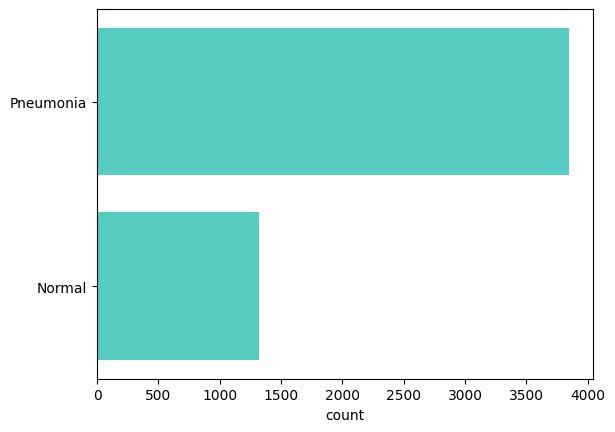

In [8]:
l = []
for i in train:
    if (i[1] == 0):
        l.append('Pneumonia')
    else:
        l.append('Normal')

sns.countplot(y=l, color='#40E0D0')

Text(0.5, 1.0, 'NORMAL')

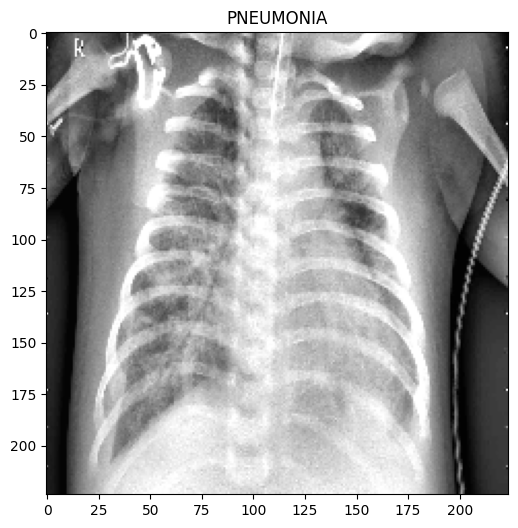

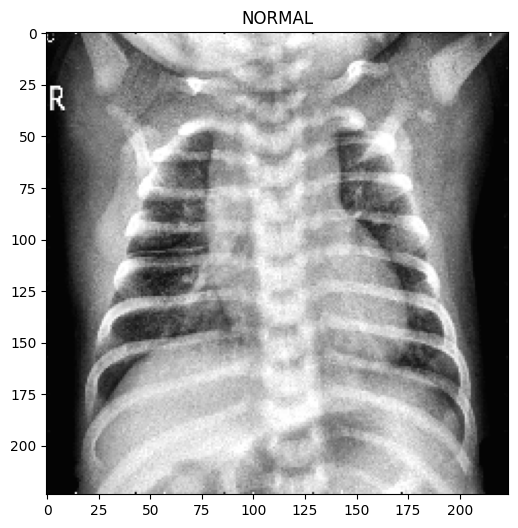

In [9]:
plt.figure(figsize=(6,6))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))
plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [10]:
x_train = []
y_train = []
for feat, label in train:
    x_train.append(feat)
    y_train.append(label)


x_val = []
y_val = []
for feat,label in val:
    x_val.append(feat)
    y_val.append(label)


x_test = []
y_test = []
for feat, label in test:
    x_test.append(feat)
    y_test.append(label)


In [11]:
# print(type(x_train))
# print(type(x_train[0]))
# print("First train image shape:", np.array(x_train[0]).shape)
# print("First val image shape:", np.array(x_val[0]).shape)
# print("First test image shape:", np.array(x_test[0]).shape)

## Normalizing       data ........

In [ ]:

import gc
import numpy as np
def memory_efficient_convert(data_list):
    if not data_list: return np.array([])
    shape = (len(data_list),) + data_list[0].shape
    arr = np.empty(shape, dtype='float32')
    for i in range(len(data_list)):
        arr[i] = data_list[i] / 255.0
        data_list[i] = None 
    gc.collect()
    return arr

x_train = memory_efficient_convert(x_train)
x_val = memory_efficient_convert(x_val)
x_test = memory_efficient_convert(x_test)


# suitable for CNN

In [13]:
x_train = np.array(x_train)
y_train = np.array(y_train)

x_val = np.array(x_val)
y_val = np.array(y_val)

x_test = np.array(x_test)
y_test = np.array(y_test)

print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

x_train shape: (5170, 224, 224, 3)
x_val shape: (62, 224, 224, 3)
x_test shape: (624, 224, 224, 3)


# data augmentation

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data__gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

data__gen.fit(x_train)

## Train........

### Semi-Supervised Learning Data Partitioning

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

SEED_RATIO = 0.30
RANDOM_SEED = 42


y_train = np.array(y_train)


dl_x, du_x, dl_y, du_y = train_test_split(
    x_train, y_train, 
    train_size=SEED_RATIO, 
    stratify=y_train, 
    random_state=RANDOM_SEED
)

print(f"Total Train: {len(x_train)}")
import gc
del x_train
del y_train
gc.collect()
print(f"D_L (Labeled): {len(dl_x)}")
print(f"D_U (Unlabeled): {len(du_x)}")


Total Train: 5170
D_L (Labeled): 1551
D_U (Unlabeled): 3619


### AdaMed Optimizer and Focal Loss

In [ ]:
import tensorflow as tf

class ClassBalancedFocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0, name="focal_loss"):
        super().__init__(name=name)
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
        loss = alpha_t * tf.math.pow((1 - p_t), self.gamma) * cross_entropy
        return tf.reduce_mean(loss)


alpha = 1318.0 / 5170.0

class AdaMed(tf.keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, gamma_align=0.1, weight_decay=1e-4, epsilon=1e-7, name="AdaMed", **kwargs):
        super().__init__(name=name, **kwargs)
        self._set_hyper("learning_rate", kwargs.get("lr", learning_rate))
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.gamma_align = gamma_align
        self.weight_decay = weight_decay
        self.epsilon = epsilon
        
    def _create_slots(self, var_list):
        for var in var_list:
            self.add_slot(var, "m")
            self.add_slot(var, "v")
            
    def _resource_apply_dense(self, grad, var, apply_state=None):
        m = self.get_slot(var, "m")
        v = self.get_slot(var, "v")
        lr = self._get_hyper("learning_rate")
        
        dot_product = tf.reduce_sum(grad * m)
        norm_g = tf.norm(grad)
        norm_m = tf.norm(m)
        rho_t = tf.clip_by_value(dot_product / (norm_g * norm_m + self.epsilon), 0.0, 1.0)
        
        m_t = self.beta_1 * m + (1.0 - self.beta_1) * (1.0 + self.gamma_align * rho_t) * grad
        v_t = self.beta_2 * v + (1.0 - self.beta_2) * tf.square(grad)
        
        wd = self.weight_decay * (2.0 - rho_t)
        var_t = var - lr * (m_t / (tf.sqrt(v_t) + self.epsilon) + wd * var)
        
        from tensorflow.keras import backend as K
        m_update = K.update(m, m_t)
        v_update = K.update(v, v_t)
        var_update = K.update(var, var_t)
        return tf.group(m_update, v_update, var_update)
        
    def get_config(self):
        config = super().get_config()
        config.update({
            "learning_rate": self._serialize_hyperparameter("learning_rate"),
            "beta_1": self.beta_1, "beta_2": self.beta_2, "gamma_align": self.gamma_align,
            "weight_decay": self.weight_decay, "epsilon": self.epsilon,
        })
        return config

### Phase A: Warm-up Model (Xception)

In [17]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, BatchNormalization

base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.30)(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)

loss_fn = ClassBalancedFocalLoss(alpha=alpha, gamma=2.0)
optimizer = AdaMed(learning_rate=1e-4)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

from tensorflow.keras.preprocessing.image import ImageDataGenerator
clean_gen = ImageDataGenerator()
history_phase_a = model.fit(
    data__gen.flow(dl_x, dl_y, batch_size=8),
    validation_data=clean_gen.flow(x_val, np.array(y_val), batch_size=8, shuffle=False),
    epochs=21
)


Epoch 1/21
194/194 [==============================] - 23s 66ms/step - loss: 0.0309 - accuracy: 0.8440 - auc: 0.9357 - val_loss: 0.0179 - val_accuracy: 0.9355 - val_auc: 0.9849
Epoch 2/21
194/194 [==============================] - 12s 62ms/step - loss: 0.0210 - accuracy: 0.9026 - auc: 0.9778 - val_loss: 0.0280 - val_accuracy: 0.9355 - val_auc: 0.9912
Epoch 3/21
194/194 [==============================] - 12s 60ms/step - loss: 0.0142 - accuracy: 0.9446 - auc: 0.9860 - val_loss: 0.0176 - val_accuracy: 0.9677 - val_auc: 0.9917
Epoch 4/21
194/194 [==============================] - 12s 62ms/step - loss: 0.0129 - accuracy: 0.9368 - auc: 0.9900 - val_loss: 0.0121 - val_accuracy: 0.9516 - val_auc: 0.9943
Epoch 5/21
194/194 [==============================] - 12s 60ms/step - loss: 0.0096 - accuracy: 0.9620 - auc: 0.9942 - val_loss: 0.0128 - val_accuracy: 0.9677 - val_auc: 0.9958
Epoch 6/21
194/194 [==============================] - 12s 61ms/step - loss: 0.0113 - accuracy: 0.9536 - auc: 0.9917 - va

### Phase B: Iterative SSL Loop

In [ ]:
TAU = 0.90
SSL_EPOCHS = 6
EPOCHS_PER_CYCLE = 14
def get_lambda(cycle, total_cycles, max_lambda=1.0):
    p = float(cycle) / total_cycles
    return max_lambda * tf.math.exp(-5.0 * (1.0 - p))


from tensorflow.keras.utils import Sequence
class CombinedSequence(Sequence):
    def __init__(self, dl_x, dl_y, du_x, confident_indices, pseudo_y, sample_weights, batch_size, datagen):
        self.dl_x = dl_x
        self.dl_y = dl_y
        self.du_x = du_x
        self.confident_indices = confident_indices
        self.pseudo_y = pseudo_y
        self.sample_weights = sample_weights
        self.batch_size = batch_size
        self.datagen = datagen
        self.total_len = len(dl_x) + len(confident_indices)
        self.indices = np.arange(self.total_len)
        np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(self.total_len / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_x, batch_y, batch_sw = [], [], []
        
        for i in batch_indices:
            if i < len(self.dl_x):
                batch_x.append(self.dl_x[i])
                batch_y.append(self.dl_y[i])
                batch_sw.append(self.sample_weights[i])
            else:
                p_i = i - len(self.dl_x)
                real_idx = self.confident_indices[p_i]
                batch_x.append(self.du_x[real_idx])
                batch_y.append(self.pseudo_y[p_i])
                batch_sw.append(self.sample_weights[i])
                
        batch_x = np.array(batch_x, dtype='float32')
        batch_y = np.array(batch_y, dtype='float32')
        batch_sw = np.array(batch_sw, dtype='float32')
        
        for j in range(len(batch_x)):
            batch_x[j] = self.datagen.random_transform(batch_x[j])
            
        return batch_x, batch_y, batch_sw
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

class PredictSequence(Sequence):
    def __init__(self, du_x, active_indices, batch_size):
        self.du_x = du_x
        self.active_indices = active_indices
        self.batch_size = batch_size
    def __len__(self):
        return int(np.ceil(len(self.active_indices) / float(self.batch_size)))
    def __getitem__(self, idx):
        batch_idx = self.active_indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_x = [self.du_x[i] for i in batch_idx]
        return np.array(batch_x, dtype='float32')


active_du_indices = np.arange(len(du_x))
global_confident_indices = []
global_pseudo_y = []

for cycle in range(SSL_EPOCHS):
    print(f'\n--- SSL Cycle {cycle + 1}/{SSL_EPOCHS} ---')
    if len(active_du_indices) == 0:
        print('No more unlabeled data left.')
        break
    
    
    pred_seq = PredictSequence(du_x, active_du_indices, 8)
    preds = model.predict(pred_seq, verbose=0).flatten()
    
    
    confident_mask = (preds >= TAU) | (preds <= (1 - TAU))
    new_confident_local_idx = np.where(confident_mask)[0]
    
    if len(new_confident_local_idx) == 0:
        print('No confident samples found in this cycle.')
        break
    
    
    new_confident_real_idx = active_du_indices[new_confident_local_idx]
    
    
    new_pseudo_y = [1 if preds[i] >= TAU else 0 for i in new_confident_local_idx]
    
    
    global_confident_indices.extend(new_confident_real_idx)
    global_pseudo_y.extend(new_pseudo_y)
    
    
    current_lambda = get_lambda(cycle, SSL_EPOCHS).numpy()
    sample_weights = np.concatenate([
        np.ones(len(dl_x)),
        np.full(len(global_confident_indices), current_lambda)
    ])
    
    
    print(f'Retraining on combined data (L:{len(dl_x)}, U_pseudo:{len(global_confident_indices)} | lambda={current_lambda:.4f})...')
    comb_seq = CombinedSequence(dl_x, dl_y, du_x, global_confident_indices, np.array(global_pseudo_y), sample_weights, 8, data__gen)
    model.fit(comb_seq, validation_data=clean_gen.flow(x_val, np.array(y_val), batch_size=8, shuffle=False), epochs=EPOCHS_PER_CYCLE)
    
    
    active_du_indices = np.delete(active_du_indices, new_confident_local_idx)



--- SSL Cycle 1/6 ---
Retraining on combined data (L:1551, U_pseudo:2407 | lambda=0.0067)...
Epoch 1/14
495/495 [==============================] - 34s 62ms/step - loss: 9.4430e-04 - accuracy: 0.9934 - auc: 0.9997 - val_loss: 0.0106 - val_accuracy: 0.9839 - val_auc: 0.9990
Epoch 2/14
495/495 [==============================] - 31s 62ms/step - loss: 4.7386e-04 - accuracy: 0.9960 - auc: 0.9999 - val_loss: 0.0044 - val_accuracy: 0.9839 - val_auc: 1.0000
Epoch 3/14
495/495 [==============================] - 30s 61ms/step - loss: 6.6576e-04 - accuracy: 0.9919 - auc: 0.9998 - val_loss: 0.0157 - val_accuracy: 0.9839 - val_auc: 0.9990
Epoch 4/14
495/495 [==============================] - 30s 61ms/step - loss: 6.4524e-04 - accuracy: 0.9952 - auc: 0.9999 - val_loss: 0.0152 - val_accuracy: 0.9839 - val_auc: 1.0000
Epoch 5/14
495/495 [==============================] - 30s 60ms/step - loss: 0.0015 - accuracy: 0.9914 - auc: 0.9989 - val_loss: 0.0095 - val_accuracy: 0.9677 - val_auc: 0.9984
Epoch 6/14

### Evaluation and Grad-CAM

Evaluating on Final Test Set...
78/78 [==============================] - 3s 33ms/step
Accuracy : 0.8814
AUC      : 0.9733
Confusion Matrix:
 [[384   6]
 [ 68 166]]


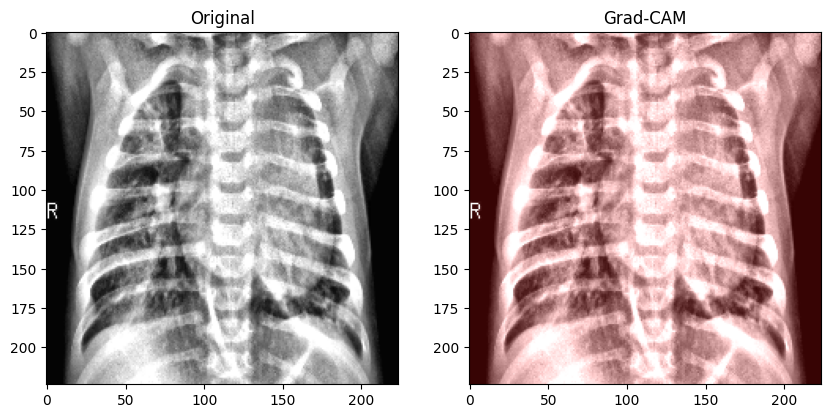

In [ ]:
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Evaluating on Final Test Set...")
y_test_np = np.array(y_test)
test_loss, test_acc, test_auc = model.evaluate(clean_gen.flow(x_test, y_test_np, batch_size=8, shuffle=False))

test_preds = model.predict(clean_gen.flow(x_test, batch_size=8, shuffle=False)).flatten()
test_preds_binary = (test_preds >= 0.5).astype(int)

print(f"Accuracy : {test_acc:.4f}")
print(f"AUC      : {test_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_np, test_preds_binary))

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    base = model.layers[1] # Xception
    grad_model = tf.keras.models.Model(
        [base.inputs], [base.get_layer(last_conv_layer_name).output, base.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, base_preds = grad_model(img_array)
        x = last_conv_layer_output
        for layer in model.layers[2:]:
            x = layer(x)
        preds = x
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_array, heatmap, alpha=0.4):
    img = np.uint8(255 * img_array[0])
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[1].imshow(superimposed_img)
    ax[1].set_title("Grad-CAM")
    plt.show()


idx = 0
heatmap = make_gradcam_heatmap(x_test[idx:idx+1], model, "block14_sepconv2_act", pred_index=0)
display_gradcam(x_test[idx:idx+1], heatmap)


In [ ]:
# Savinggg Semi-Supervised Model
print(f"Saving finalized model to {MODEL_PATH}...")
model.save(MODEL_PATH)
print("Model saved successfully!")

Saving finalized model to C:\CODES__SSD512\minorP_Pneumonia\Notebooks\Major_Project\H5\custom_E27_CLAHE_Contrast_Xception_P4I3A3M7T4.keras...
Model saved successfully!
